In [543]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.special import expit
from scipy.stats import logistic
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from sps_common.constants import DM_CONSTANT, FREQ_BOTTOM, FREQ_TOP, TSAMP
from ps_processes.processes.ps_inject import gaussian
from astropy.coordinates import SkyCoord 
from astropy import units as u

In [544]:
# data_1 = np.concatenate((np.loadtxt('single_day_20260402_results.txt'),
#                          np.loadtxt('single_day_2026_04_05_injections.txt'),
#                          np.loadtxt('single_day_2026_04_08_injections.txt'),
#                          np.loadtxt('single_day_2026_04_11_injections.txt'),
#                          np.loadtxt('single_day_2026_04_14_injections.txt'),
#                          np.loadtxt('1_day_injections.txt')))
# data_1[:, 2] = 1
# data_2 = np.unique(np.loadtxt('2_day_injections.txt'), axis = 0)
# data_3 = np.unique(np.loadtxt('3_day_injections.txt'), axis = 0)
# data_4 = np.unique(np.loadtxt('4_day_injections.txt'), axis = 0)
# data_5 = np.unique(np.loadtxt('5_day_injections.txt'), axis = 0)
# data_5 = np.unique(np.loadtxt('5_day_injections.txt'), axis = 0)
# data_6 = np.unique(np.loadtxt('6_day_injections.txt'), axis = 0)
# data_7 = np.unique(np.loadtxt('7_day_injections.txt'), axis = 0)
# data_8 = np.unique(np.loadtxt('8_day_injections.txt'), axis = 0)
# data_9 = np.unique(np.loadtxt('9_day_injections.txt'), axis = 0)
# data_10 = np.unique(np.loadtxt('10_day_injections.txt'), axis = 0)
# data_11 = np.unique(np.loadtxt('11_day_injections.txt'), axis = 0)
# data_12 = np.unique(np.loadtxt('12_day_injections.txt'), axis = 0)
# data_13 = np.unique(np.loadtxt('13_day_injections.txt'), axis = 0)
# data_14 = np.unique(np.loadtxt('14_day_injections.txt'), axis = 0)
# data_15 = np.unique(np.loadtxt('15_day_injections.txt'), axis = 0)
# data_16 = np.unique(np.loadtxt('16_day_injections.txt'), axis = 0)
# data_17 = np.unique(np.loadtxt('17_day_injections.txt'), axis = 0)
# data_18 = np.unique(np.loadtxt('18_day_injections.txt'), axis = 0)
# data_19 = np.unique(np.loadtxt('19_day_injections.txt'), axis = 0)
# data_20 = np.unique(np.loadtxt('20_day_injections.txt'), axis = 0)
# data_21 = np.unique(np.loadtxt('21_day_injections.txt'), axis = 0)
# data_22 = np.unique(np.loadtxt('22_day_injections.txt'), axis = 0)
# data_23 = np.unique(np.loadtxt('23_day_injections.txt'), axis = 0)
# data_24 = np.unique(np.loadtxt('24_day_injections.txt'), axis = 0)
# data_25 = np.unique(np.loadtxt('25_day_injections.txt'), axis = 0)
# data_26 = np.unique(np.loadtxt('26_day_injections.txt'), axis = 0)
# data_27 = np.unique(np.loadtxt('27_day_injections.txt'), axis = 0)
# data_28 = np.unique(np.loadtxt('28_day_injections.txt'), axis = 0)
# data_29 = np.unique(np.loadtxt('29_day_injections.txt'), axis = 0)
# data_30 = np.unique(np.loadtxt('30_day_injections.txt'), axis = 0)
# data_31 = np.unique(np.loadtxt('31_day_injections.txt'), axis = 0)
# data_32 = np.unique(np.loadtxt('32_day_injections.txt'), axis = 0)
# data_33 = np.unique(np.loadtxt('33_day_injections.txt'), axis = 0)
# data_34 = np.unique(np.loadtxt('34_day_injections.txt'), axis = 0)
# data_35 = np.unique(np.loadtxt('35_day_injections.txt'), axis = 0)
#data_36 = np.loadtxt('36_day_injections.txt')

f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
predicted_sigma_idx = 8
output_sigma_idx = 10

data = np.unique(np.loadtxt('rednoise_fix_injections.txt'), axis = 0)

In [545]:
# p_total = []

# data_unglob = [
#      data_1,
#     data_2,
#     data_3,
#     #data_4,
#     #data_5,
#     #data_9,
#      data_10,
#     data_11,
#     data_12,
#     data_13,
#     data_14,
#    data_15,
#     data_16,
#     data_17,
#     data_18,
#    data_19,
#     data_20,
#    data_21,
#    data_22,
#    data_23,
#    data_24,
#    data_25,
#    data_26,
#   data_27,
#   data_28,
#     data_29,
#     data_30,
#    data_31,
#    data_32,
#    #data_33,
#    #data_34,
#    #data_35,
#    #data_36
# ]

# data = []
# days = []

# data_sum = 0

# for datum in data_unglob:
#     data_sum += len(datum)


# for datum in data_unglob:

    
#     fglob_mask = (datum[:, f_idx] > 0.1) & (datum[:, f_idx] < 250.)
#     DMglob_mask = (datum[:, DM_idx] > 1.) & (datum[:, DM_idx] < 400.)
#     DM_good_mask = (np.abs(datum[:, 5] - datum[:, -1]) <= 1.) | (datum[:, -1] < 0)
#     FWHMglob_mask = (datum[:, FWHM_idx] > 0.006) & (datum[:, FWHM_idx] < 0.046)
#     #RAglob_mask = datum[:, 0] > 70
#     #Decglob_mask = datum[:, 1] > 40
#     glob_mask = fglob_mask & DMglob_mask & FWHMglob_mask & DM_good_mask 
#     datum = datum[glob_mask]

#     p = len(datum[datum[:, -1] > 0.]) / len(datum)
#     print(f'{int(datum[0, 2])}-day stack: {len(datum)} injections, p({int(datum[0, 2])}) = {p:.2f}')
#     p_total.append(p)
#     days.append(datum[0, 2])

#     data.append(datum)

# days = np.array(days)

# data_sum
    
days = np.unique(data[:, 2])
p_total = []
fglob_mask = (data[:, f_idx] > 0.1) & (data[:, f_idx] < 250.)
DMglob_mask = (data[:, DM_idx] > 1.) & (data[:, DM_idx] < 400.)
DM_good_mask = (np.abs(data[:, 5] - data[:, -1]) <= 1.) | (data[:, -1] < 0)
FWHMglob_mask = (data[:, FWHM_idx] > 0.006) & (data[:, FWHM_idx] < 0.046)
glob_mask = fglob_mask & DMglob_mask & FWHMglob_mask & DM_good_mask 
data_glob = data[glob_mask]

for i in range(len(days)):
    day_mask = data_glob[:, 2] == days[i]
    success_mask = data_glob[:, -1] > 0.
    p = len(data_glob[day_mask & success_mask]) / len(data_glob[day_mask])
    print(f'{int(days[i])}-day stack: {len(data_glob[day_mask])} injections, p({int(days[i])}) = {p:.2f}')
    p_total.append(p)

1-day stack: 13556 injections, p(1) = 0.40
2-day stack: 495 injections, p(2) = 0.43
3-day stack: 2336 injections, p(3) = 0.43
4-day stack: 23 injections, p(4) = 0.26
5-day stack: 17 injections, p(5) = 0.47
6-day stack: 69 injections, p(6) = 0.45
7-day stack: 139 injections, p(7) = 0.47
8-day stack: 286 injections, p(8) = 0.57
9-day stack: 103 injections, p(9) = 0.58
10-day stack: 535 injections, p(10) = 0.49
11-day stack: 1039 injections, p(11) = 0.54
12-day stack: 118 injections, p(12) = 0.56
13-day stack: 9 injections, p(13) = 0.56
14-day stack: 17 injections, p(14) = 0.53
15-day stack: 51 injections, p(15) = 0.57
16-day stack: 69 injections, p(16) = 0.54
17-day stack: 95 injections, p(17) = 0.47
18-day stack: 227 injections, p(18) = 0.55
19-day stack: 494 injections, p(19) = 0.49
20-day stack: 625 injections, p(20) = 0.57
21-day stack: 1082 injections, p(21) = 0.53
22-day stack: 1344 injections, p(22) = 0.56
23-day stack: 1922 injections, p(23) = 0.55
24-day stack: 2425 injections, 

Text(0, 0.5, 'p(N)')

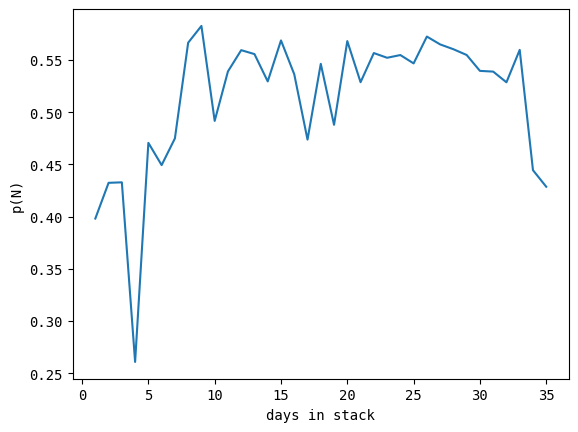

In [546]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

In [547]:
def get_cross_point(S, y):

    X = sm.add_constant(S)
    model = sm.Logit(y, X).fit()
    param_samples = np.random.multivariate_normal(model.params, 
                                                  model.cov_params(), 
                                                  size=10000)

    s0_samples = -param_samples[:, 0] / param_samples[:, 1]

    s0_fit = s0_samples.mean()
    s0_err = s0_samples.std()
    print(f"S at P=0.5: {s0_fit:.4f} ± {s0_err:.4f}")

    return s0_fit, s0_err

def bootstrap(S, y, n_boot = 10000):

    s0_boot = []

    for _ in range(n_boot):
        idx = np.random.choice(len(S), size=len(S), replace=True)
        S_boot, y_boot = S[idx], y[idx]
        
        X_boot = sm.add_constant(S_boot)
        model_boot = sm.Logit(y_boot, X_boot).fit(disp=False)
        
        intercept, slope = model_boot.params
        s0_boot.append(-intercept / slope)

    s0_err = np.std(s0_boot)
    print(f"S at P=0.5: {np.mean(s0_boot):.4f} ± {s0_err:.4f}")

    return np.mean(s0_boot), s0_err

In [548]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_hot = np.zeros(len(days))
S_cold = np.zeros(len(days))

S_hot_err = np.zeros(len(days))
S_cold_err = np.zeros(len(days))

def logistic_4p(s, k, s0, upper):
    return expit(k * (s - s0)) * upper


for i in range(len(days)):

    day_mask = data_glob[:, 2] == days[i]
    datum = data_glob[day_mask]

    coords = SkyCoord(ra=datum[:, 0]*u.deg, dec=datum[:, 1]*u.deg, frame='icrs')
    galactic_lat = coords.galactic.b
    low_b_mask = np.abs(galactic_lat) < 10*u.degree
    high_b_mask = np.abs(galactic_lat) > 10*u.degree 
    
    print(f'Hot {days[i]}-day stack: {len(datum[low_b_mask])} samples.')
    print(f'Cold {days[i]}-day stack: {len(datum[high_b_mask])} samples.')

    S = datum[:, S_idx] 
    y = (datum[:, -1] > 0.).astype(int)
    
    if len(datum[low_b_mask]) > 400:
        
        s0_fit, s0_err = bootstrap(S[low_b_mask], y[low_b_mask])
        S_hot[i] = s0_fit
        S_hot_err[i] = s0_err
    
    else: 
        S_hot[i] = np.nan
        S_hot_err[i] = np.nan
    
    if len(datum[high_b_mask]) > 400:

        s0_fit, s0_err = bootstrap(S[high_b_mask], y[high_b_mask])
        S_cold[i] = s0_fit
        S_cold_err[i] = s0_err

    else:
        S_cold[i] = np.nan
        S_cold_err[i] = np.nan
    # fig, ax = plt.subplots()
    # ax.scatter(data[i][low_b_mask, S_idx], y_hot, s = 0.1, color = 'r', alpha=0.1)
    # ax.plot(S_range, y_pred_hot, color="red", label="Hot")
    # ax.plot(S_hot[i], 0.5, 'y*')
    # ax.scatter(data[i][high_b_mask, S_idx], y_cold, s = 0.1, color = 'b', alpha=0.1)
    # ax.plot(S_range, y_pred_cold, color="blue", label="Cold")
    # ax.plot(S_cold[i], 0.5, 'y*')
    # ax.set_xlabel("S")
    # ax.set_ylabel("P")
    # ax.set_xscale('log')
    # ax.legend()
    # plt.show()





Hot 1.0-day stack: 160 samples.
Cold 1.0-day stack: 13396 samples.
S at P=0.5: 0.9959 ± 0.0331
Hot 2.0-day stack: 346 samples.
Cold 2.0-day stack: 149 samples.
Hot 3.0-day stack: 0 samples.
Cold 3.0-day stack: 2336 samples.
S at P=0.5: 0.7625 ± 0.0654
Hot 4.0-day stack: 23 samples.
Cold 4.0-day stack: 0 samples.
Hot 5.0-day stack: 17 samples.
Cold 5.0-day stack: 0 samples.
Hot 6.0-day stack: 57 samples.
Cold 6.0-day stack: 12 samples.
Hot 7.0-day stack: 115 samples.
Cold 7.0-day stack: 24 samples.
Hot 8.0-day stack: 127 samples.
Cold 8.0-day stack: 159 samples.
Hot 9.0-day stack: 0 samples.
Cold 9.0-day stack: 103 samples.
Hot 10.0-day stack: 4 samples.
Cold 10.0-day stack: 531 samples.
S at P=0.5: 0.2802 ± 0.0179
Hot 11.0-day stack: 0 samples.
Cold 11.0-day stack: 1039 samples.
S at P=0.5: 0.3385 ± 0.0417
Hot 12.0-day stack: 0 samples.
Cold 12.0-day stack: 118 samples.
Hot 13.0-day stack: 9 samples.
Cold 13.0-day stack: 0 samples.
Hot 14.0-day stack: 7 samples.
Cold 14.0-day stack: 10

Lorimer & Kramer:
$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \text{SNR} $$

where $\delta$ is the effective width.

Assuming that we will find >50% of everything with SNR > 10, and choosing $b = 0^{\circ}$ and $l = 90^{\circ}$:

In [558]:
GAIN = 1.16e-3  # K mJy^-1
TSYS = 50  # K
BETA = 1.1
NPOL = 2
TAU = 20* 10 * 60 #s
F_NYQUIST = 508 #Hz
BANDWIDTH = 400e6 #Hz

#envelope functions:
def get_nchans(maxdm):
    """
    Inputs a pointing dict with ra, dec, maxdm and returns nchans.

    Inputs
    pointing - A dict of ra, dec, maxdm
    """
    if maxdm <= 212.5:
        nchans = 1024
    elif maxdm <= 425:
        nchans = 2048
    elif maxdm <= 850:
        nchans = 4096
    elif maxdm <= 1700:
        nchans = 8192
    else:
        nchans = 16384
    return nchans


def get_dedispersion_time():

    #max DM offset we can have for channelization of 0.1 pcc
    delta_DM = 0.05 #pc / cm^-3 
    
    dt = DM_CONSTANT * delta_DM * (1/FREQ_BOTTOM**2 - 1/FREQ_TOP**2)
    
    return dt

def time_windowing(prof_fft, f):
    # apply Van der Klis Eq 2.19 for time-bin windowing effect
    harmonic_freqs = np.arange(1, len(prof_fft) + 1) * f
    B = np.sinc(harmonic_freqs * TSAMP)
    prof_fft *= B

    return prof_fft

def get_intrachannel_time(DM, maxDM):
        
    nchan = get_nchans(maxDM)

    quadratic_terms = {
            "1024": 1e-8,
            "2048": 6e-9,
            "4096": 3e-9,
            "8192": 1.5e-9,
            "16384": 8e-10,
        }
    quadratic_term = quadratic_terms[str(nchan)]

    t_intrachannel = DM * DM_CONSTANT * quadratic_term
    
    return t_intrachannel

def radiometer(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    FWHM /= f #in s
    tau = Ndays * 10 * 60 #days x minutes / day x seconds / minute
 
    t_dedisp = get_dedispersion_time() #in s
    t_intrach = get_intrachannel_time(DM, maxDM)
    
    FWHM = np.sqrt(FWHM**2 + t_dedisp**2 )
    FWHM = np.sqrt(FWHM**2 + t_intrach**2)
    FWHM = np.sqrt(FWHM**2 + TSAMP**2)

    system_terms =  BETA * (TSYS + Tsky) / GAIN
    obs_terms = 1 / np.sqrt(NPOL * tau * (BANDWIDTH / 2)) #for rfi...
    pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM)) 

    return system_terms * obs_terms * pulse_terms * SNR

def get_Scurve(f, DM, SNR, FWHM, maxDM, Tsky, Ndays):

    Smin = np.zeros((len(DM), len(f)))

    for k in range(len(DM)):
        for l in range(len(f)):
            S_temp = radiometer(f[l], DM[k], SNR, FWHM, maxDM, Tsky, Ndays)
            Smin[k, l] = S_temp

    return Smin


In [559]:
def power_law(x, A, alpha):

    return A * x**alpha

# par_hot = curve_fit(power_law, days, S_hot, p0 = (1, -0.5))
# par_cold = curve_fit(power_law, days, S_cold, p0 = (1, -0.5))

# print(f'alpha_hot = {par_hot[0][1]:.2f}')
# print(f'alpha_cold = {par_cold[0][1]:.2f}')

In [560]:
many_days = np.linspace(0.2, 33)
Smin_hot_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_hot_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 100., Ndays = many_days) 
Smin_cold_mid = radiometer(f = 1, DM = 0, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 
Smin_cold_fast = radiometer(f = 100, DM = 212.5, SNR = 7., FWHM = 0.026, maxDM = 212.5, Tsky = 10., Ndays = many_days) 

(0.023138921308270555, 13.121371734219267)

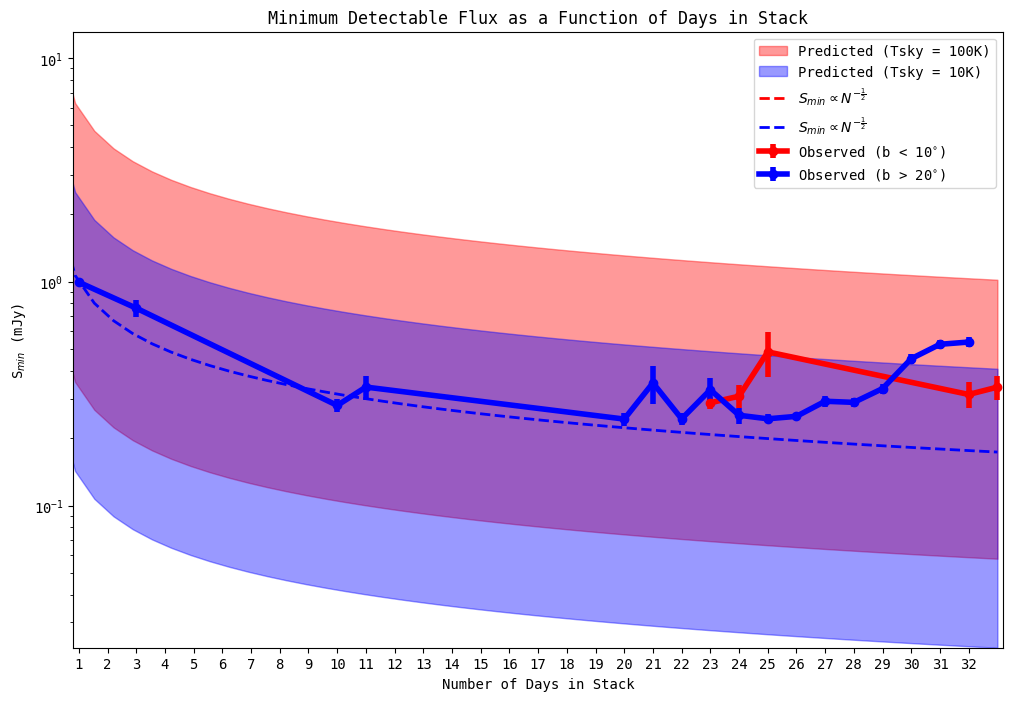

In [561]:

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
ymax = max(Smin_hot_fast)

mask_hot = np.isfinite(Smin_hot_fast)
mask_cold = np.isfinite(Smin_cold_fast)

upper_hot = np.where(mask_hot, Smin_hot_fast, ymax)
upper_cold = np.where(mask_cold, Smin_cold_fast, ymax)

hot_nanmask = np.isnan(S_hot) 
cold_nanmask = np.isnan(S_cold)

ax.fill_between(many_days, Smin_hot_mid, Smin_hot_fast,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(many_days, Smin_cold_mid, Smin_cold_fast,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')
# ax.plot(days[~hot_nanmask], S_hot[~hot_nanmask], 'r', marker = 'o', linewidth = '4.0', 
#         label = r'Observed (b < 10$^{\circ}$)')
# ax.plot(days[~cold_nanmask], S_cold[~cold_nanmask], 'b', marker = 'o', linewidth = '4.0', 
#         label = r'Observed (b > 20$^{\circ}$)')
ax.errorbar(days[~hot_nanmask], S_hot[~hot_nanmask], yerr = S_hot_err[~hot_nanmask], 
            color = 'r', marker = 'o', linewidth = 4., 
         label = r'Observed (b < 10$^{\circ}$)')
ax.errorbar(days[~cold_nanmask], S_cold[~cold_nanmask], yerr = S_cold_err[~cold_nanmask], 
            color = 'b', marker = 'o', linewidth = 4., 
         label = r'Observed (b > 20$^{\circ}$)')
ax.plot(many_days, power_law(many_days, S_hot[0], -0.5), 'r--', linewidth = '2.0',
        label = r'$S_{min} \propto N^{-\frac{1}{2}}$')
ax.plot(many_days, power_law(many_days, S_cold[0], -0.5), 'b--', linewidth = '2.0', 
        label = r'$S_{min} \propto N^{-\frac{1}{2}}$')


# ax.set_xlim(np.nanmin(many_days), np.nanmax(many_days))
# ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

ax.legend()
ax.set_xticks(range(1, 33))
ax.set_xlabel('Number of Days in Stack')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.set_yscale('log')
ax.set_title('Minimum Detectable Flux as a Function of Days in Stack')
ax.set_xlim(0.8, 33.2)
ax.set_ylim(np.nanmin(Smin_cold_mid), np.nanmax(Smin_hot_fast))

Below is a really complicated way of sorting all our data into chunks based off the channelization.

In [553]:
all_data = np.concatenate(data_unglob, axis = 0)
coords = SkyCoord(ra=all_data[:, 0]*u.deg, dec=all_data[:, 1]*u.deg, frame='icrs')
galactic_lat = coords.galactic.b
low_b_mask = np.abs(galactic_lat) < 5*u.degree
high_b_mask = np.abs(galactic_lat) > 10*u.degree 

f_bins = np.logspace(np.log10(0.05), np.log10(250), 500)
f_dev = 50
S_bins = np.logspace(-2, 1, 500)
S_dev = 50

Smin_of_f = np.zeros((4, len(f_bins) - 1))
FWHM_lazarus_mask = (all_data[:, FWHM_idx] > 0.014) & (all_data[:, FWHM_idx] < 0.034)
DM_mask = (all_data[:, DM_idx] > 1.) 
length_mask = all_data[:, 2] == 14

print(f'Analyzing {len(all_data[FWHM_lazarus_mask & DM_mask & length_mask & low_b_mask])} low-b injections.')
print(f'Analyzing {len(all_data[FWHM_lazarus_mask & DM_mask & length_mask & high_b_mask])} high-b injections.')

'''
_____________________
HOT SKY
'''
_, f_S_unsmooth_hot, f_S_smooth_hot = au.get_sensitivity(
    all_data[FWHM_lazarus_mask & DM_mask & low_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[0, j] = np.min(S_bins[np.where(f_S_smooth_hot[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

'''
_____________________
COLD SKY
'''
_, f_S_unsmooth_cold, f_S_smooth_cold = au.get_sensitivity(
    all_data[FWHM_lazarus_mask & DM_mask & high_b_mask],
    *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
    stype = '2d',
)

for j in range(len(f_bins) - 1):

    try:
        Smin_of_f[1, j] = np.min(S_bins[np.where(f_S_smooth_cold[j] > 0.50)[0]])
    except:
        Smin_of_f[0, j] = np.nan

Smin_of_f[0] = gaussian_filter(Smin_of_f[0], 5)
Smin_of_f[1] = gaussian_filter(Smin_of_f[1], 5)


predicted_Smin_of_f = np.zeros((4, len(f_bins) - 1))
#shape is:
#hot sky, max DM 
#cold sky, max DM 
#hot sky, min DM 
#cold sky, min DM
predicted_Smin_of_f[0] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[1] = radiometer(f = f_bins[:-1], DM = 212.5, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)
predicted_Smin_of_f[2] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 100, Ndays = 14)
predicted_Smin_of_f[3] = radiometer(f = f_bins[:-1], DM = 0, SNR = 10, FWHM = 0.026, maxDM = 212.5, Tsky  = 10, Ndays = 14)

Analyzing 359 low-b injections.
Analyzing 7432 high-b injections.


/tmp/ipykernel_2130863/215501640.py:78: RuntimeWarning: invalid value encountered in sqrt
  pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM))


Text(0.5, 1.0, 'Minimum Detectable Flux for 2 Week Stacks')

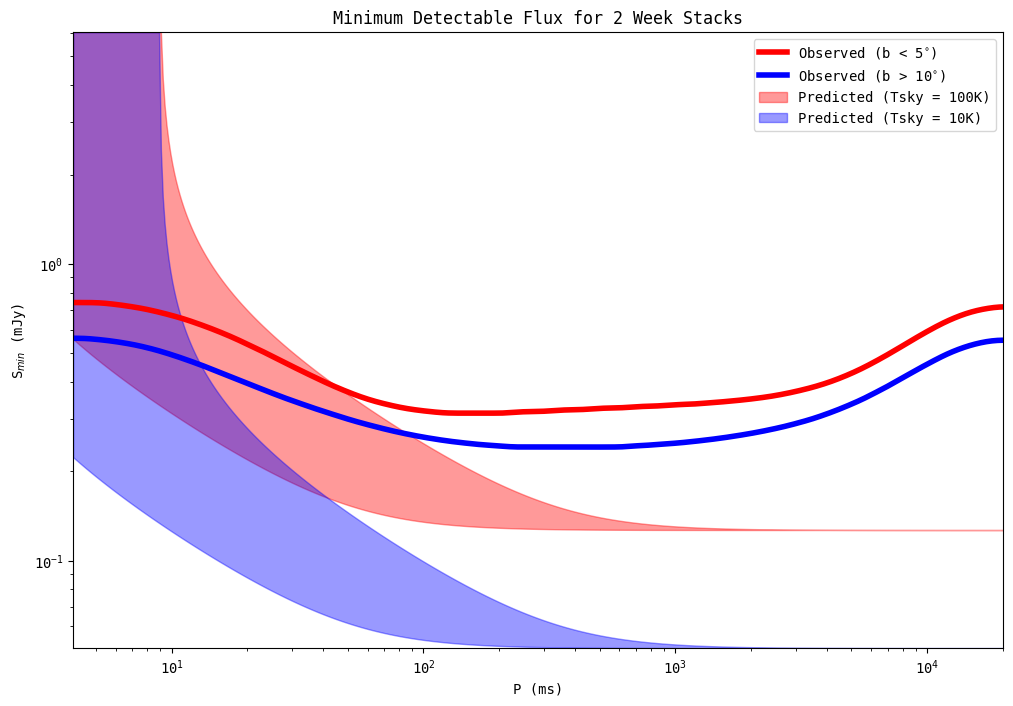

In [554]:
P = 1/f_bins[:-1]
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.plot(P*1e3, Smin_of_f[0], 'r', linewidth=4.0, label=r'Observed (b < 5$^{\circ}$)')
ax.plot(P*1e3, Smin_of_f[1], 'b', linewidth=4.0, label=r'Observed (b > 10$^{\circ}$)')

ax.loglog()
ymax = max(predicted_Smin_of_f[0])

mask_hot = np.isfinite(predicted_Smin_of_f[0])
mask_cold = np.isfinite(predicted_Smin_of_f[1])

upper_hot = np.where(mask_hot, predicted_Smin_of_f[0], ymax)
upper_cold = np.where(mask_cold, predicted_Smin_of_f[1], ymax)

ax.fill_between(P*1e3, predicted_Smin_of_f[2], upper_hot,
                color='r', alpha=0.4, label='Predicted (Tsky = 100K)')
ax.fill_between(P*1e3, predicted_Smin_of_f[3], upper_cold,
                color='b', alpha=0.4, label='Predicted (Tsky = 10K)')

ax.set_xlabel('P (ms)')
ax.set_ylabel(r'S$_{min}$ (mJy)')
ax.legend()
ax.set_xlim(min(P*1e3), max(P*1e3))
ax.set_ylim(min(predicted_Smin_of_f[3]), max(predicted_Smin_of_f[0]))
ax.set_title('Minimum Detectable Flux for 2 Week Stacks')

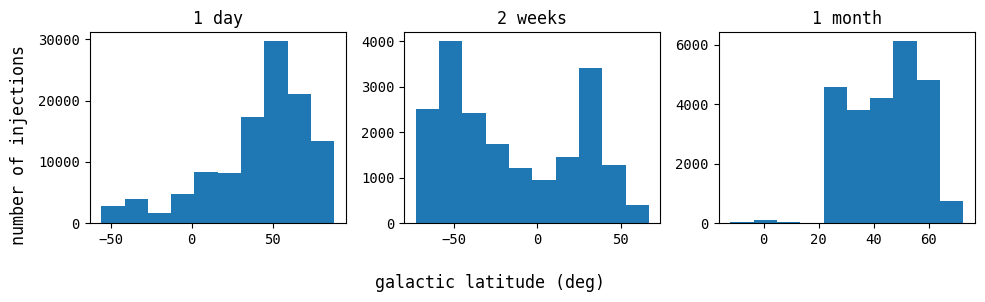

In [555]:
coords = SkyCoord(ra=data_1[:, 0]*u.deg, dec=data_1[:, 1]*u.deg, frame='icrs')
b_1= coords.galactic.b

coords = SkyCoord(ra=data_14[:, 0]*u.deg, dec=data_14[:, 1]*u.deg, frame='icrs')
b_14 = coords.galactic.b

coords = SkyCoord(ra=data_30[:, 0]*u.deg, dec=data_30[:, 1]*u.deg, frame='icrs')
b_30 = coords.galactic.b

counts_1, bins_1 = np.histogram(b_1)
counts_14, bins_14 = np.histogram(b_14)
counts_30, bins_30 = np.histogram(b_30)

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_14[:-1], bins_14, weights=counts_14)
ax[2].hist(bins_30[:-1], bins_30, weights=counts_30)

fig.supxlabel('galactic latitude (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()

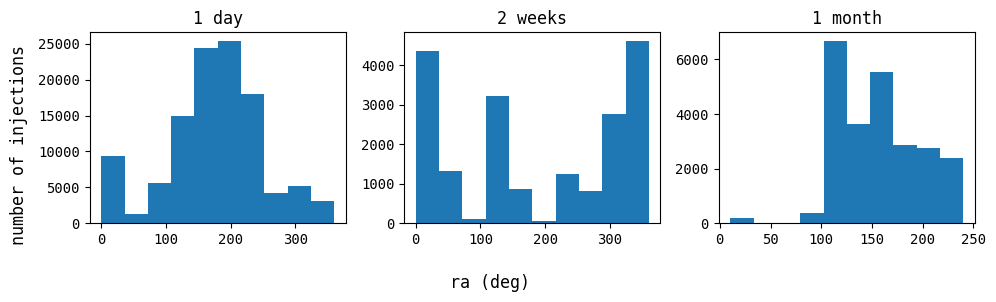

In [556]:
counts_1, bins_1 = np.histogram(data_1[:, 0])
counts_14, bins_14 = np.histogram(data_14[:, 0])
counts_30, bins_30 = np.histogram(data_30[:, 0])

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_14[:-1], bins_14, weights=counts_14)
ax[2].hist(bins_30[:-1], bins_30, weights=counts_30)

fig.supxlabel('ra (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()

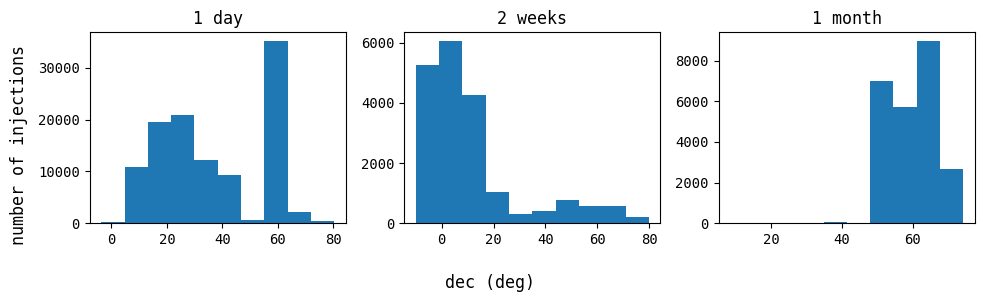

In [557]:
counts_1, bins_1 = np.histogram(data_1[:, 1])
counts_14, bins_14 = np.histogram(data_14[:, 1])
counts_30, bins_30 = np.histogram(data_30[:, 1])

fig, ax = plt.subplots(1, 3, figsize = (10, 3))

ax[0].hist(bins_1[:-1], bins_1, weights=counts_1)
ax[1].hist(bins_14[:-1], bins_14, weights=counts_14)
ax[2].hist(bins_30[:-1], bins_30, weights=counts_30)

fig.supxlabel('dec (deg)')
fig.supylabel('number of injections')

ax[0].set_title('1 day')
ax[1].set_title('2 weeks')
ax[2].set_title('1 month')

plt.tight_layout()